# LIV Golf Player Valuation Model

## The Problem
LIV Golf does not publish Strokes Gained (SG) data — the gold-standard skill metric used across professional golf analytics. Traditional stats (driving distance, fairway %, GIR, scrambling, putting average) are available, but they don't decompose skill the way SG does.

## The Solution
We have a decade of PGA Tour data where **both** traditional stats and SG values are known for the same player-seasons. We train a regression model on this paired dataset, then apply it to LIV stats to produce **estimated SG values** for LIV players.

This is methodologically defensible: the underlying physics of golf shots don't change between tours. A player hitting 72% of fairways on LIV is exhibiting the same skill as a player hitting 72% on the PGA Tour — the relationship between traditional stats and stroke-value should transfer.

## Output
- Per-player estimated SG (OTT, App, ATG, Putt, Total) for each LIV season
- A ranked player valuation table with confidence intervals
- Identification of over/underperformers relative to their skill profile

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.utils import resample
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
GOLD = '#C9A84C'
NAVY = '#0A1628'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#F8F8F8'})

PGA_CSV  = '../../PGA_Prediction_Tools/data/raw/individual_yoy_statistics.csv'
LIV_STATS_CSV = '../02_player_dashboard/data/liv_season_stats.csv'
LIV_RESULTS_CSV = '../02_player_dashboard/data/liv_event_results.csv'


## 1. Build PGA Tour Training Dataset
Melt the wide PGA CSV (one column per year × stat) into a long format: one row per player-year with features and targets side by side.

In [91]:
raw = pd.read_csv(PGA_CSV, low_memory=False)

# Column mapping: wide-format suffix → clean name
FEATURE_MAP = {
    'Driving_Distance_Avg':            'drive_dist',
    'Driving_Accuracy_Percentage_':    'fairway_pct',
    'Greens_or_Fringe_in_Regulation_': 'gir_pct',
    'Scrambling_':                     'scrambling_pct',
    'Putting_Average_Avg':             'putting_avg',
    'Birdie_Average_Avg':              'birdies_per_round',
}
TARGET_MAP = {
    'SG_Total_Avg':              'sg_total',
    'SG_Off_the_Tee_Avg':        'sg_ott',
    'SG_Approach_the_Green_Avg': 'sg_app',
    'SG_Around_the_Green_Avg':   'sg_atg',
    'SG_Tee_to_Green_Avg':       'sg_t2g',
}

records = []
for yr in range(2010, 2026):
    row_data = {'year': yr}
    feat_cols = {f'{yr}_{k}': v for k, v in FEATURE_MAP.items()}
    tgt_cols  = {f'{yr}_{k}': v for k, v in TARGET_MAP.items()}
    present_feats = {k: v for k, v in feat_cols.items() if k in raw.columns}
    present_tgts  = {k: v for k, v in tgt_cols.items()  if k in raw.columns}

    for _, row in raw.iterrows():
        r = {'playerName': row['playerName'], 'year': yr}
        for col, name in present_feats.items():
            val = row.get(col)
            if isinstance(val, str):
                val = str(val).replace('%', '').strip()
            try:
                r[name] = float(val)
            except (ValueError, TypeError):
                r[name] = np.nan
        for col, name in present_tgts.items():
            try:
                r[name] = float(row.get(col))
            except (ValueError, TypeError):
                r[name] = np.nan
        records.append(r)

pga = pd.DataFrame(records)

# Derive SG Putting = Total - T2G
pga['sg_putt'] = pga['sg_total'] - pga['sg_t2g']

# ── Engineered feature: tee-to-fairway effectiveness ──────────────────────────
# Long AND accurate off the tee is synergistic — this interaction term
# captures that better than either feature alone.
pga['dist_x_fairway'] = pga['drive_dist'] * pga['fairway_pct'] / 100.0

# Drop rows missing any feature or target
FEATURES = [
    'drive_dist', 'fairway_pct', 'gir_pct', 'scrambling_pct',
    'putting_avg', 'birdies_per_round', 'dist_x_fairway',
]
TARGETS  = ['sg_total', 'sg_ott', 'sg_app', 'sg_atg', 'sg_putt']
pga_clean = pga.dropna(subset=TARGETS).reset_index(drop=True)  # features may be NaN; XGBoost handles them

print(f'Training rows (player-seasons with complete data): {len(pga_clean):,}')
print(f'Unique players: {pga_clean.playerName.nunique()}')
print(f'Years covered: {pga_clean.year.min()}–{pga_clean.year.max()}')
print(f'\nFeatures used: {FEATURES}')
pga_clean[FEATURES + TARGETS].describe().round(3)

Training rows (player-seasons with complete data): 3,005
Unique players: 629
Years covered: 2010–2025

Features used: ['drive_dist', 'fairway_pct', 'gir_pct', 'scrambling_pct', 'putting_avg', 'birdies_per_round', 'dist_x_fairway']


,drive_dist,fairway_pct,gir_pct,scrambling_pct,putting_avg,birdies_per_round,dist_x_fairway,sg_total,sg_ott,sg_app,sg_atg,sg_putt
count,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000,3005.000
mean,294.467,61.187,71.337,58.671,1.769,3.647,179.914,0.140,0.036,0.058,0.020,0.025
std,9.774,5.094,3.137,3.443,0.027,0.327,12.842,0.702,0.368,0.381,0.226,0.343
min,266.400,43.020,58.120,44.010,1.667,2.380,124.285,-3.454,-1.717,-2.115,-0.932,-1.475
25%,287.800,57.740,69.350,56.470,1.751,3.430,171.986,-0.267,-0.177,-0.180,-0.123,-0.189
50%,294.300,61.220,71.460,58.750,1.769,3.640,180.372,0.144,0.051,0.077,0.026,0.039
75%,300.900,64.660,73.470,60.970,1.787,3.850,189.028,0.564,0.271,0.306,0.173,0.257
max,326.300,76.880,81.820,70.730,1.888,4.960,219.179,2.743,1.485,1.533,0.702,1.131


## 2. Exploratory Analysis — Feature–Target Correlations

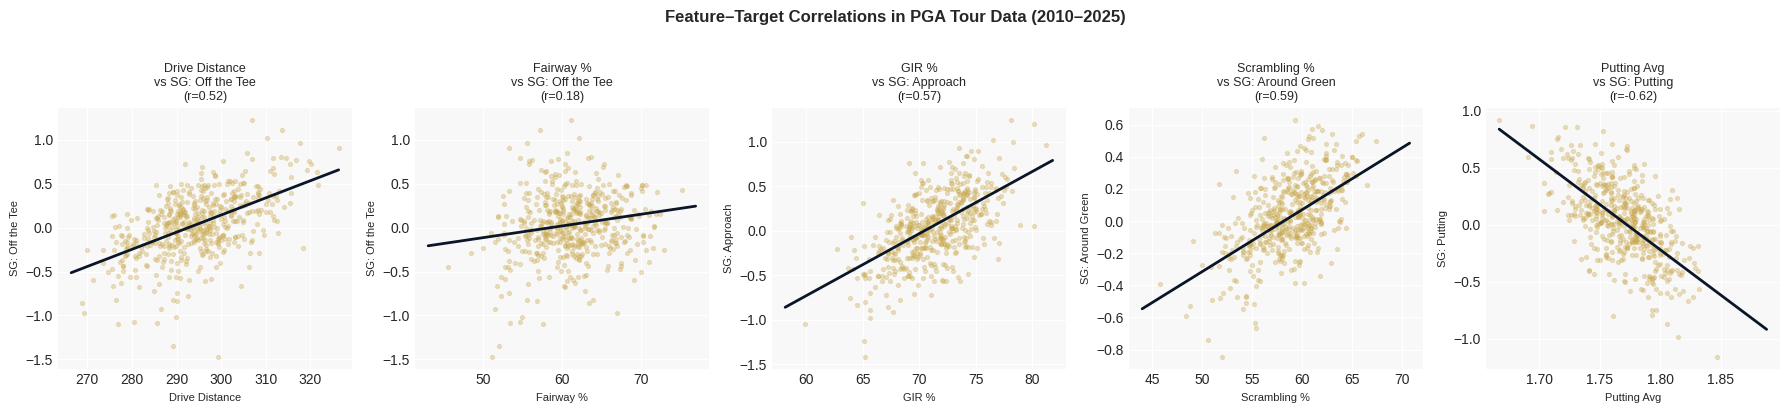

In [92]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
feat_labels = ['Drive Dist', 'Fairway %', 'GIR %', 'Scrambling %', 'Putting Avg']
tgt_labels  = ['SG Total', 'SG OTT', 'SG App', 'SG ATG', 'SG Putt']

pairs = list(zip(FEATURES, TARGETS[1:] + [TARGETS[0]], feat_labels, tgt_labels[1:] + [tgt_labels[0]]))
pairs = [
    ('drive_dist',      'sg_ott',   'Drive Distance',  'SG: Off the Tee'),
    ('fairway_pct',     'sg_ott',   'Fairway %',       'SG: Off the Tee'),
    ('gir_pct',         'sg_app',   'GIR %',           'SG: Approach'),
    ('scrambling_pct',  'sg_atg',   'Scrambling %',    'SG: Around Green'),
    ('putting_avg',     'sg_putt',  'Putting Avg',     'SG: Putting'),
]

for ax, (feat, tgt, fx, ty) in zip(axes, pairs):
    sample = pga_clean.sample(min(500, len(pga_clean)), random_state=42)
    ax.scatter(sample[feat], sample[tgt], alpha=0.3, s=8, color=GOLD)
    # Trend line
    z = np.polyfit(pga_clean[feat], pga_clean[tgt], 1)
    xr = np.linspace(pga_clean[feat].min(), pga_clean[feat].max(), 100)
    ax.plot(xr, np.polyval(z, xr), color=NAVY, linewidth=2)
    r = pga_clean[[feat, tgt]].corr().iloc[0, 1]
    ax.set_title(f'{fx}\nvs {ty}\n(r={r:.2f})', fontsize=9)
    ax.set_xlabel(fx, fontsize=8)
    ax.set_ylabel(ty, fontsize=8)

plt.suptitle('Feature–Target Correlations in PGA Tour Data (2010–2025)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

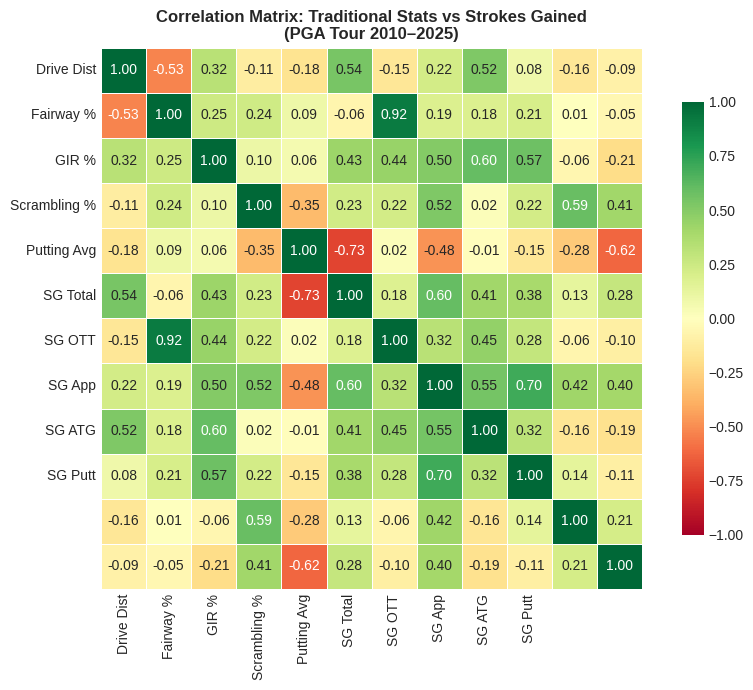

In [93]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = pga_clean[FEATURES + TARGETS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax,
    xticklabels=feat_labels + tgt_labels,
    yticklabels=feat_labels + tgt_labels,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix: Traditional Stats vs Strokes Gained\n(PGA Tour 2010–2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Training — Ridge vs Gradient Boosting vs Ensemble

We compare three approaches:
- **Ridge Regression**: L2-regularized linear model — interpretable, stable, handles multicollinearity
- **Gradient Boosting (GBR)**: Tree-based ensemble — captures non-linear relationships and feature interactions
- **Ensemble (Voting)**: Blends Ridge + GBR predictions, averaging out each model's weaknesses

All models use **player-grouped 5-fold cross-validation** (GroupKFold) to prevent leakage — the model is never evaluated on a player it trained on. The ensemble is used for final LIV projections.

In [94]:
X = pga_clean[FEATURES].values
groups = pga_clean['playerName'].values
gkf = GroupKFold(n_splits=5)

# ── Model definition — XGBoost handles NaN features natively ─────────────────
def make_xgb():
    return XGBRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        n_jobs=-1, random_state=42,
    )

models_final = {}   # XGB models used for LIV projection

print(f'{"":12s}  {"XGB R²":>12s}  {"MAE":>10s}')
print('-' * 40)
for tgt in TARGETS:
    y = pga_clean[tgt].values
    xgb = make_xgb()
    scores = cross_val_score(xgb, X, y, cv=gkf, groups=groups,
                              scoring='r2', n_jobs=-1)
    xgb.fit(X, y)
    models_final[tgt] = xgb
    mae = mean_absolute_error(y, xgb.predict(X))
    print(f'{tgt:12s}  '
          f'{scores.mean():+.3f}±{scores.std():.3f}  '
          f'{mae:.3f}')


                    XGB R²         MAE
----------------------------------------
sg_total      +0.573±0.008  0.241
sg_ott        +0.572±0.055  0.124
sg_app        +0.339±0.017  0.165
sg_atg        +0.328±0.027  0.097
sg_putt       +0.430±0.056  0.136


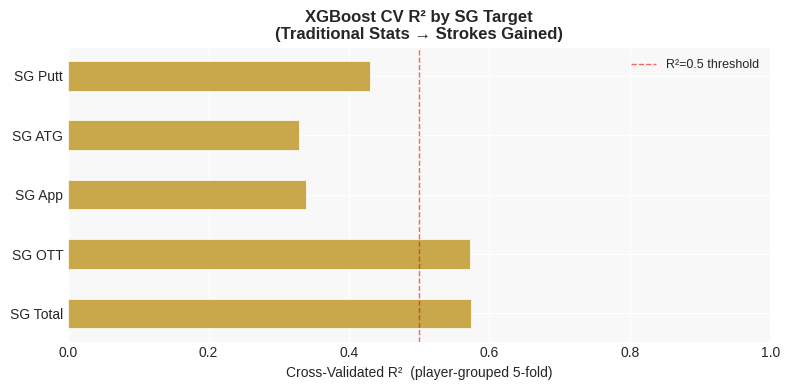

In [95]:
# ── CV R² for XGBoost by SG target ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

tgt_labels = ['SG Total', 'SG OTT', 'SG App', 'SG ATG', 'SG Putt']
xgb_means = [cross_val_score(make_xgb(), pga_clean[FEATURES].values,
                               pga_clean[t].values, cv=gkf,
                               groups=pga_clean['playerName'].values,
                               scoring='r2', n_jobs=-1).mean()
              for t in TARGETS]

y_pos = np.arange(len(TARGETS))
ax.barh(y_pos, xgb_means, 0.5, color=GOLD, edgecolor='white', linewidth=0.5)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, linewidth=1, label='R²=0.5 threshold')
ax.set_yticks(y_pos)
ax.set_yticklabels(tgt_labels, fontsize=10)
ax.set_xlabel('Cross-Validated R²  (player-grouped 5-fold)', fontsize=10)
ax.set_title('XGBoost CV R² by SG Target\n(Traditional Stats → Strokes Gained)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison_r2.png', dpi=150, bbox_inches='tight')
plt.show()


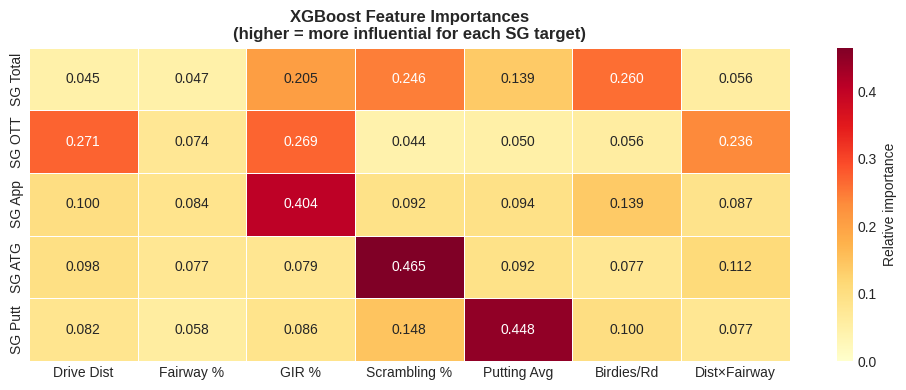


Mean XGB importance across all SG targets:
GIR %           0.209
Scrambling %    0.199
Putting Avg     0.165
Birdies/Rd      0.127
Drive Dist      0.119
Dist×Fairway    0.114
Fairway %       0.068


In [96]:
feat_labels = ['Drive Dist', 'Fairway %', 'GIR %', 'Scrambling %',
               'Putting Avg', 'Birdies/Rd', 'Dist×Fairway']
tgt_labels  = ['SG Total', 'SG OTT', 'SG App', 'SG ATG', 'SG Putt']

# ── XGBoost feature importances (averaged across targets) ─────────────────────
imp_matrix = np.zeros((len(TARGETS), len(FEATURES)))
for ti, tgt in enumerate(TARGETS):
    imp_matrix[ti] = models_final[tgt].feature_importances_

imp_df = pd.DataFrame(imp_matrix, index=tgt_labels, columns=feat_labels)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=imp_df.values.max(),
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Relative importance'})
ax.set_title('XGBoost Feature Importances\n(higher = more influential for each SG target)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean XGB importance across all SG targets:')
mean_imp = pd.Series(imp_matrix.mean(axis=0), index=feat_labels).sort_values(ascending=False)
print(mean_imp.round(3).to_string())


## 4. Model Validation — Predicted vs Actual SG

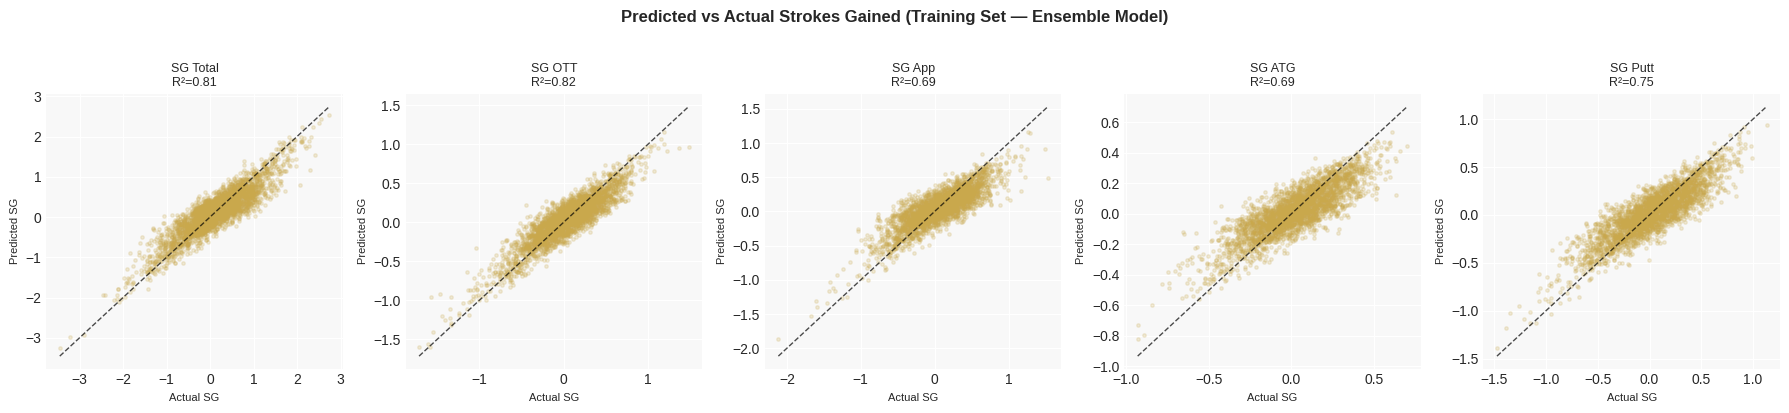

In [97]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
tgt_labels  = ['SG Total', 'SG OTT', 'SG App', 'SG ATG', 'SG Putt']

for ax, tgt, label in zip(axes, TARGETS, tgt_labels):
    y_true = pga_clean[tgt].values
    y_pred = models_final[tgt].predict(X)
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color=GOLD)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7, label='Perfect')
    ax.set_xlabel('Actual SG', fontsize=8)
    ax.set_ylabel('Predicted SG', fontsize=8)
    ax.set_title(f'{label}\nR²={r2:.2f}', fontsize=9)

plt.suptitle('Predicted vs Actual Strokes Gained (Training Set — Ensemble Model)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Apply Model to LIV Golf Stats
Load the scraped LIV season stats and project estimated SG values for each player-season.

In [98]:
liv_raw = pd.read_csv(LIV_STATS_CSV)
print(f'LIV season stats: {len(liv_raw)} rows')
print(f'Seasons: {sorted(liv_raw.season.unique())}')
print(f'Players: {liv_raw.playerName.nunique()}')
liv_raw.head()

LIV season stats: 286 rows
Seasons: [2022, 2023, 2024, 2025, 2026]
Players: 104


,playerName,season,team,birdies_per_round,drive_distance,eagles,fairway_pct,gir_pct,putting_avg,scrambling_pct
0,Abraham Ancer,2022,Fireballs GC,74.0,302.5,3.0,76.98,70.99,1.64,50.00
1,Abraham Ancer,2023,Fireballs GC,168.0,299.0,2.0,72.56,68.80,1.60,58.90
2,Abraham Ancer,2024,Fireballs GC,180.0,299.8,2.0,67.32,70.14,1.57,60.47
3,Abraham Ancer,2025,Fireballs GC,162.0,302.7,3.0,67.86,67.36,1.60,60.00
4,Abraham Ancer,2026,Torque GC,43.0,285.4,2.0,62.50,70.83,1.51,71.43


In [99]:

# LIV column → model feature mapping
LIV_FEAT_MAP = {
    'drive_distance':  'drive_dist',
    'fairway_pct':     'fairway_pct',
    'gir_pct':         'gir_pct',
    'scrambling_pct':  'scrambling_pct',
    'putting_avg':     'putting_avg',
    # birdies_per_round: season total — normalized below
}

liv = liv_raw.rename(columns=LIV_FEAT_MAP).copy()

for col in ['fairway_pct', 'gir_pct', 'scrambling_pct']:
    if col in liv.columns:
        liv[col] = pd.to_numeric(
            liv[col].astype(str).str.replace('%', '').str.strip(), errors='coerce'
        )

# ── Normalize LIV birdies: CSV stores season totals, need per-round rate ──────
# Derive events played per player-season from the results CSV
results_raw = pd.read_csv(LIV_RESULTS_CSV)
results_raw['year'] = results_raw['year'].astype(int)
# Strip trailing ' -' scraper artefacts so names match the season stats CSV
results_raw['playerName'] = (
    results_raw['playerName']
    .str.strip()
    .str.replace(r'\s*-\s*$', '', regex=True)
)
season_events = (
    results_raw.groupby(['playerName', 'year'])['event_slug']
    .nunique()
    .reset_index()
    .rename(columns={'year': 'season', 'event_slug': 'events_played'})
)
# Also compute season-wide event counts as fallback
total_events_by_season = results_raw.groupby('year')['event_slug'].nunique().to_dict()

liv['season'] = liv['season'].astype(int)
liv = liv.merge(season_events, on=['playerName', 'season'], how='left')
# Fallback: use season total events for players missing from results CSV
liv['events_played'] = liv['events_played'].fillna(
    liv['season'].map(total_events_by_season).fillna(13)
)
liv['birdies_per_round'] = liv['birdies_per_round'] / (liv['events_played'] * 3)

# ── Engineered feature (same formula as PGA training data) ────────────────────
liv['dist_x_fairway'] = liv['drive_dist'] * liv['fairway_pct'] / 100.0

# ── Filter to only player-seasons where the player actually played ─────────
# The scraper copies stats into seasons where a player wasn't yet competing.
# season_events (built above) contains only real (playerName, season) pairs.
valid_seasons = season_events[['playerName', 'season']].copy()
n_before = len(liv)
liv = liv.merge(valid_seasons, on=['playerName', 'season'], how='inner').reset_index(drop=True)
print(f'LIV rows after filtering to actual played seasons: {len(liv)} (dropped {n_before - len(liv)} fabricated rows)')

# Keep all remaining LIV rows — XGBoost handles NaN features natively
liv_clean = liv.copy()

# ── Quantile-match LIV features to PGA distributional scale ──────────────────
# QuantileTransformer cannot accept NaN — use median imputer first, then transform.
# The imputed values are only used for the quantile alignment step; the originals
# (with NaN) are passed directly to XGBoost.
qt_pga = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(500, len(pga_clean)),
    random_state=42,
)
qt_pga.fit(pga_clean[FEATURES].values)

# Fit imputer on LIV data to fill NaN before quantile transform
imputer = SimpleImputer(strategy='median')
X_liv_raw = imputer.fit_transform(liv_clean[FEATURES].values)

liv_for_qt = pd.DataFrame(X_liv_raw, columns=FEATURES)
liv_unique_vals = liv_for_qt.drop_duplicates()
qt_liv = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(50, len(liv_unique_vals)),
    random_state=42,
)
qt_liv.fit(liv_unique_vals.values)

X_liv_normal = qt_liv.transform(X_liv_raw)
X_liv_scaled = qt_pga.inverse_transform(X_liv_normal)

print('\nLIV features after quantile-mapping to PGA scale:')
print(pd.DataFrame(X_liv_scaled, columns=FEATURES).describe().round(3))

# ── Project SG using XGBoost model ───────────────────────────────────────────
for tgt in TARGETS:
    liv_clean[f'est_{tgt}'] = models_final[tgt].predict(X_liv_scaled)

print('\nProjected SG for first 10 rows:')
liv_clean[['playerName', 'season', 'team'] + [f'est_{t}' for t in TARGETS]].head(10)


LIV rows after filtering to actual played seasons: 280 (dropped 6 fabricated rows)

LIV features after quantile-mapping to PGA scale:
       drive_dist  fairway_pct  gir_pct  scrambling_pct  putting_avg  \
count     280.000      280.000  280.000         280.000      280.000   
mean      294.465       61.219   71.345          58.652        1.769   
std         9.896        5.166    3.175           3.581        0.027   
min       266.400       43.020   58.120          44.010        1.667   
25%       287.786       57.628   69.363          56.498        1.754   
50%       294.335       61.213   71.494          58.761        1.769   
75%       300.917       64.693   73.460          61.000        1.787   
max       326.300       76.880   81.820          70.730        1.888   

       birdies_per_round  dist_x_fairway  
count            280.000         280.000  
mean               3.647         179.884  
std                0.334          12.944  
min                2.380         124.285  
25

,playerName,season,team,est_sg_total,est_sg_ott,est_sg_app,est_sg_atg,est_sg_putt
0,Abraham Ancer,2022,Fireballs GC,0.222466,0.450657,0.328566,-0.173560,-0.428819
1,Abraham Ancer,2023,Fireballs GC,0.118627,0.212504,0.064789,-0.172030,-0.011623
2,Abraham Ancer,2024,Fireballs GC,0.437229,0.201953,0.121322,0.006346,0.076959
3,Abraham Ancer,2025,Fireballs GC,0.151879,0.210013,0.075363,-0.062236,-0.094776
4,Abraham Ancer,2026,Torque GC,1.895164,-0.140508,0.764728,0.285668,0.641909
5,Adrian Meronk,2024,Cleeks Golf Club,0.376870,0.225083,0.160093,-0.058956,0.176161
6,Adrian Meronk,2025,Cleeks Golf Club,-0.262951,-0.046443,-0.336300,-0.160403,0.093084
7,Adrian Meronk,2026,Cleeks Golf Club,0.390189,-0.432668,0.613032,0.323293,0.010283
8,Adrian Otaegui,2022,Torque GC,-0.380519,-0.324507,-0.585013,0.276194,0.274673
9,Andy Ogletree,2022,Torque GC,-2.268678,-1.245092,-1.279357,0.017555,0.265819


## 6. LIV Player Valuation Table
Combine estimated SG with actual LIV leaderboard performance to identify over/underperformers.

In [100]:
results = pd.read_csv(LIV_RESULTS_CSV)
results['year'] = results['year'].astype(int)

def avg_finish(pos_str):
    try:
        return int(str(pos_str).replace('T', ''))
    except:
        return np.nan

results['position_num'] = results['position'].apply(avg_finish)
results['season'] = results['year'].astype(str)

perf = results.groupby(['playerName', 'season']).agg(
    events_played=('event_slug', 'nunique'),
    avg_position=('position_num', 'mean'),
    avg_total=('total_to_par', 'mean'),
    top10s=('position_num', lambda x: (x <= 10).sum()),
    wins=('position_num', lambda x: (x == 1).sum()),
).reset_index()

# liv_clean has a temporary events_played column from birdie normalization;
# drop it so the authoritative value from perf (results-derived) takes precedence.
liv_for_val = liv_clean.drop(columns=['events_played'], errors='ignore').copy()
liv_for_val['season'] = liv_for_val['season'].astype(str)

valuation = liv_for_val.merge(perf, on=['playerName', 'season'], how='left')

# Focus on 2025 season for the headline table
val_2025 = valuation[valuation['season'] == '2025'].copy()
val_2025 = val_2025.sort_values('est_sg_total', ascending=False)

display_cols = ['playerName', 'team', 'est_sg_total', 'est_sg_ott',
                'est_sg_app', 'est_sg_atg', 'est_sg_putt',
                'events_played', 'avg_position', 'top10s', 'wins']
val_2025[display_cols].head(20).round(3)

,playerName,team,est_sg_total,est_sg_ott,est_sg_app,est_sg_atg,est_sg_putt,events_played,avg_position,top10s,wins
43,Bryson DeChambeau,Crushers GC,1.052,0.698,-0.073,-0.001,0.124,13.0,11.000,7.0,1.0
149,Jon Rahm,Legion XIII,0.856,0.661,0.401,0.033,-0.058,13.0,5.308,12.0,0.0
263,Thomas Pieters,NaN,0.605,0.330,0.042,0.059,0.145,13.0,18.846,4.0,0.0
145,Joaquin Niemann,Torque GC,0.531,0.795,0.168,-0.224,0.070,13.0,13.077,6.0,5.0
212,Patrick Reed,NaN,0.506,0.261,0.072,0.105,0.124,13.0,16.385,6.0,1.0
173,Lucas Herbert,Ripper GC,0.452,0.232,-0.208,0.125,0.336,13.0,23.692,3.0,0.0
61,Cameron Tringale,HyFlyers GC,0.420,0.162,0.051,-0.007,0.207,13.0,19.077,3.0,0.0
71,Charl Schwartzel,Southern Guards GC,0.419,-0.006,-0.083,0.105,0.319,13.0,21.077,2.0,0.0
56,Cameron Smith,Ripper GC,0.419,0.112,-0.086,0.245,0.327,13.0,16.231,5.0,0.0
88,David Puig,Fireballs GC,0.381,0.479,-0.061,0.063,0.072,12.0,12.500,4.0,0.0


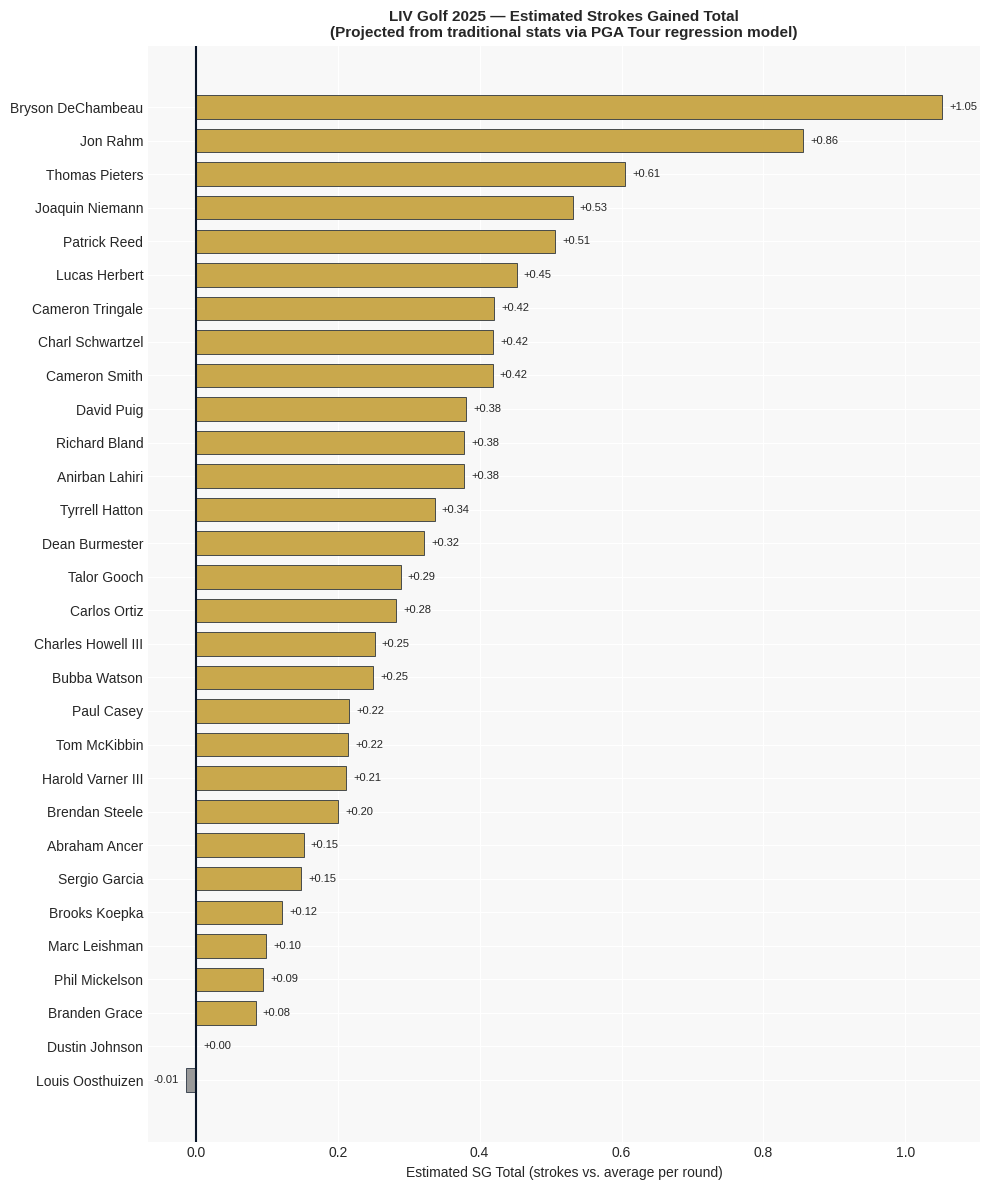

In [101]:
# Visualization: Estimated SG Total ranking — 2025 LIV field
fig, ax = plt.subplots(figsize=(10, 12))

plot_df = val_2025.nlargest(30, 'est_sg_total')[['playerName', 'est_sg_total']]
colors = [GOLD if v > 0 else '#999' for v in plot_df['est_sg_total']]

bars = ax.barh(plot_df['playerName'], plot_df['est_sg_total'],
               color=colors, edgecolor=NAVY, linewidth=0.5, height=0.7)
ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_xlabel('Estimated SG Total (strokes vs. average per round)', fontsize=10)
ax.set_title('LIV Golf 2025 — Estimated Strokes Gained Total\n'
             '(Projected from traditional stats via PGA Tour regression model)',
             fontweight='bold', fontsize=11)
ax.invert_yaxis()
for bar, val in zip(bars, plot_df['est_sg_total']):
    ax.text(val + 0.01 if val >= 0 else val - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('liv_2025_sg_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

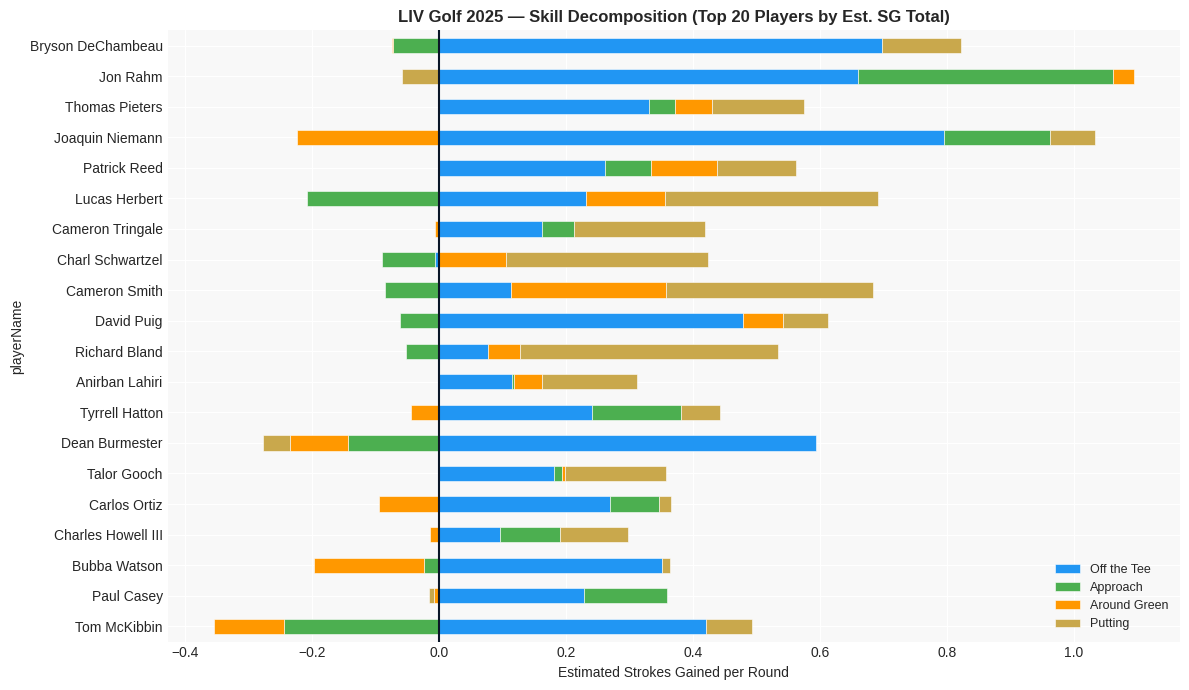

In [102]:
# Skill decomposition — stacked bar by SG component
top20 = val_2025.nlargest(20, 'est_sg_total').set_index('playerName')
sg_components = top20[['est_sg_ott', 'est_sg_app', 'est_sg_atg', 'est_sg_putt']]
sg_components.columns = ['Off the Tee', 'Approach', 'Around Green', 'Putting']

comp_colors = ['#2196F3', '#4CAF50', '#FF9800', GOLD]
fig, ax = plt.subplots(figsize=(12, 7))
sg_components.plot(kind='barh', stacked=True, ax=ax,
                   color=comp_colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_xlabel('Estimated Strokes Gained per Round', fontsize=10)
ax.set_title('LIV Golf 2025 — Skill Decomposition (Top 20 Players by Est. SG Total)',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('skill_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 6b. Prediction Intervals — Quantifying Estimate Uncertainty

**90% cross-validation prediction intervals** derived from out-of-fold ensemble residuals on PGA Tour training data.

The interval `[ci_lo, ci_hi]` answers: *"For 90% of PGA Tour player-seasons, the true SG fell within this range of the model's prediction."*

Because intervals are derived from residuals (actual − predicted), the point estimate always lies within its CI by construction — `q05 ≤ 0 ≤ q95` so `estimate + q05 ≤ estimate ≤ estimate + q95`. Width reflects overall model accuracy for each SG target.

Computing cross-val residuals for prediction intervals (ensemble)...
90% residual interval: [-0.713, +0.774] SG strokes


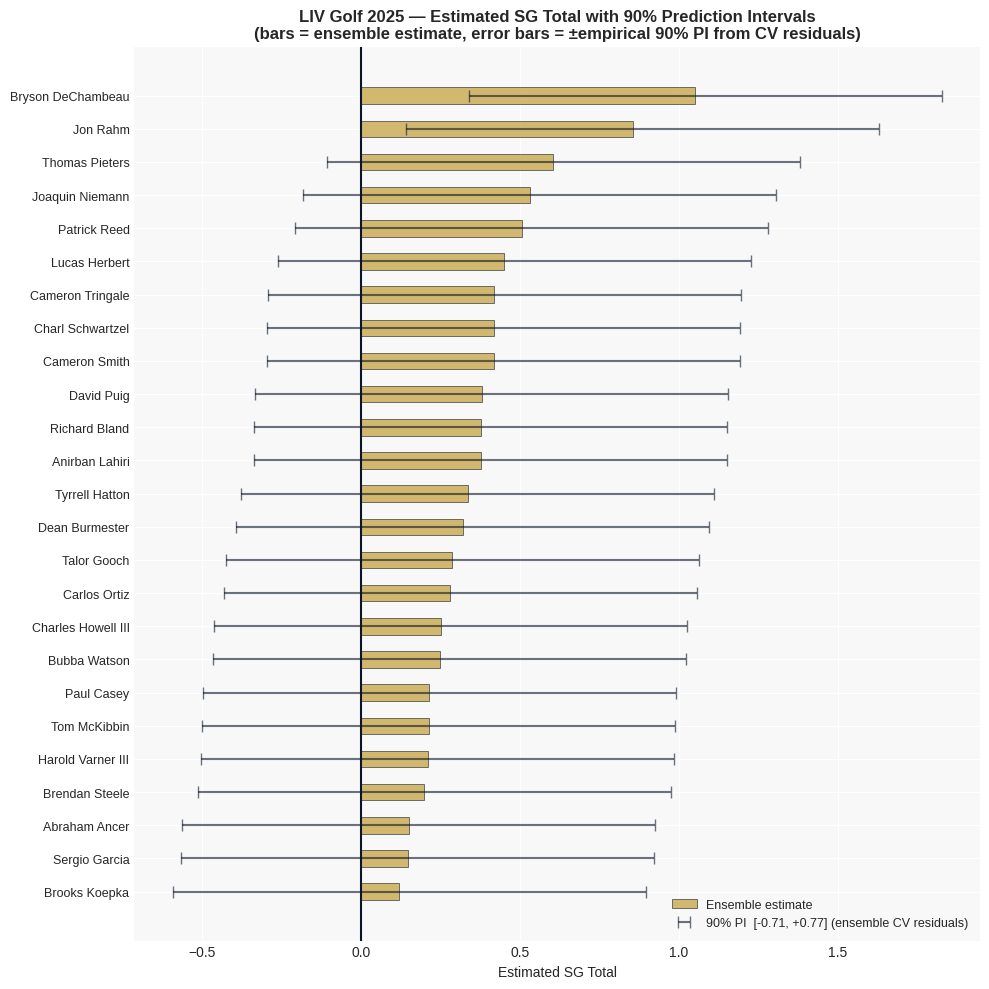


90% PI width: 1.487 SG strokes (same for all players — reflects model accuracy, not player-specific uncertainty)

Top 25 — 2025 estimates with prediction intervals:
        playerName  est_sg_total  ci_lo  ci_hi
 Bryson DeChambeau         1.052  0.339  1.826
          Jon Rahm         0.856  0.144  1.631
    Thomas Pieters         0.605 -0.107  1.380
   Joaquin Niemann         0.531 -0.182  1.305
      Patrick Reed         0.506 -0.207  1.280
     Lucas Herbert         0.452 -0.261  1.226
  Cameron Tringale         0.420 -0.292  1.195
  Charl Schwartzel         0.419 -0.293  1.194
     Cameron Smith         0.419 -0.294  1.193
        David Puig         0.381 -0.332  1.155
     Richard Bland         0.379 -0.334  1.153
    Anirban Lahiri         0.378 -0.335  1.152
    Tyrrell Hatton         0.337 -0.376  1.111
    Dean Burmester         0.322 -0.391  1.096
       Talor Gooch         0.289 -0.424  1.063
      Carlos Ortiz         0.282 -0.431  1.056
Charles Howell III         0.252 -0

In [103]:

# ── Cross-validation prediction intervals (90%) ───────────────────────────────
# Compute out-of-fold ensemble predictions on the PGA training set.
# Residuals (actual - predicted) are the empirical error distribution.
# q05 (negative) and q95 (positive) give a 90% PI that by construction
# always contains the point estimate: est + q05 ≤ est ≤ est + q95.

print('Computing cross-val residuals for prediction intervals (ensemble)...')
y_cv_pred_sg = cross_val_predict(
    make_xgb(), X, pga_clean['sg_total'].values,
    cv=gkf, groups=groups,
)
residuals = pga_clean['sg_total'].values - y_cv_pred_sg   # actual − predicted

q05 = np.percentile(residuals, 5)
q95 = np.percentile(residuals, 95)
print(f'90% residual interval: [{q05:+.3f}, {q95:+.3f}] SG strokes')

# Apply offset to every LIV ensemble estimate
liv_clean = liv_clean.copy()
liv_clean['ci_lo']    = liv_clean['est_sg_total'] + q05
liv_clean['ci_hi']    = liv_clean['est_sg_total'] + q95
liv_clean['ci_mid']   = liv_clean['est_sg_total']         # point estimate is center by construction
liv_clean['ci_width'] = q95 - q05                         # constant across players

# ── Visualize: 2025 top players with error bars ───────────────────────────────
val_2025_ci = liv_clean[liv_clean['season'] == 2025].copy()
val_2025_ci = val_2025_ci.sort_values('est_sg_total', ascending=False).head(25).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 10))
y_pos = np.arange(len(val_2025_ci))

ax.barh(y_pos, val_2025_ci['est_sg_total'], height=0.5,
        color=[GOLD if v > 0 else '#aaa' for v in val_2025_ci['est_sg_total']],
        edgecolor=NAVY, linewidth=0.5, alpha=0.8, label='Ensemble estimate')

# Both half-widths are positive by construction
xerr_lo = val_2025_ci['est_sg_total'] - val_2025_ci['ci_lo']  # = |q05|
xerr_hi = val_2025_ci['ci_hi'] - val_2025_ci['est_sg_total']  # = q95
ax.errorbar(
    val_2025_ci['est_sg_total'], y_pos,
    xerr=[xerr_lo, xerr_hi],
    fmt='none', color=NAVY, capsize=4, linewidth=1.5, alpha=0.6,
    label=f'90% PI  [{q05:+.2f}, {q95:+.2f}] (ensemble CV residuals)',
)

ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(val_2025_ci['playerName'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Estimated SG Total', fontsize=10)
ax.set_title('LIV Golf 2025 — Estimated SG Total with 90% Prediction Intervals\n'
             '(bars = ensemble estimate, error bars = ±empirical 90% PI from CV residuals)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('liv_2025_sg_with_ci.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n90% PI width: {q95 - q05:.3f} SG strokes (same for all players — reflects model accuracy, not player-specific uncertainty)')
print('\nTop 25 — 2025 estimates with prediction intervals:')
print(val_2025_ci[['playerName', 'est_sg_total', 'ci_lo', 'ci_hi']]
      .round(3).to_string(index=False))


## 8. Multi-Season Trajectory & Consistency Analysis

Track how each player's estimated SG has evolved across the LIV era (2022–2025).
Players with monotonically improving or declining trends are flagged.
Consistency is measured as the **standard deviation of finish positions** across all events — lower = more consistent results.

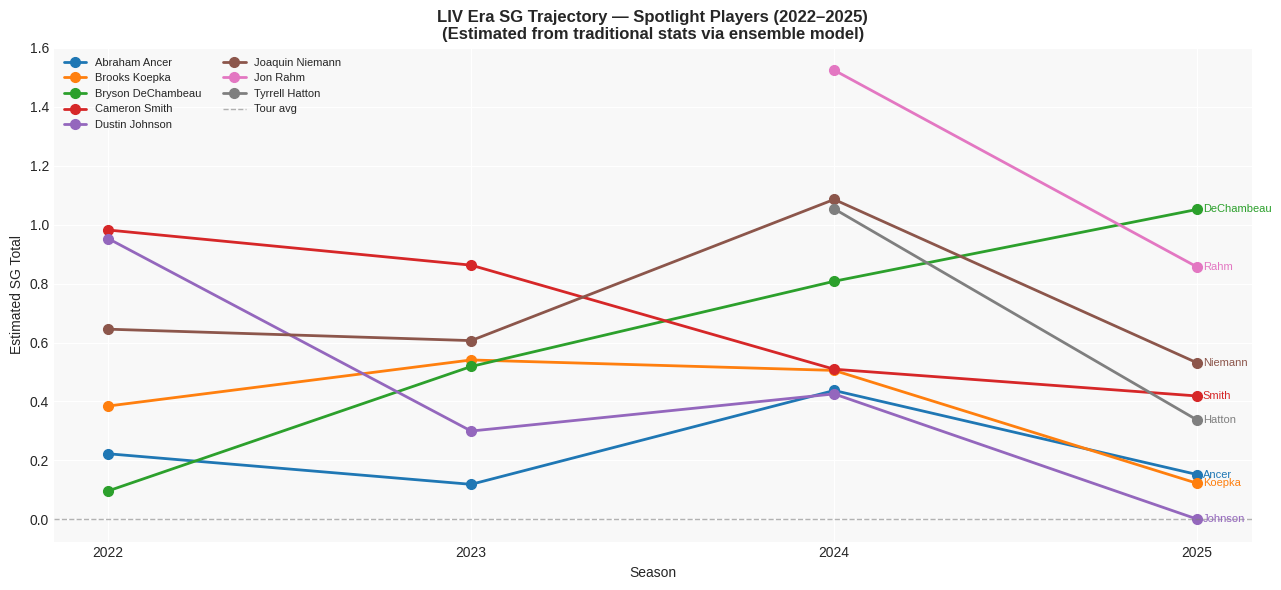

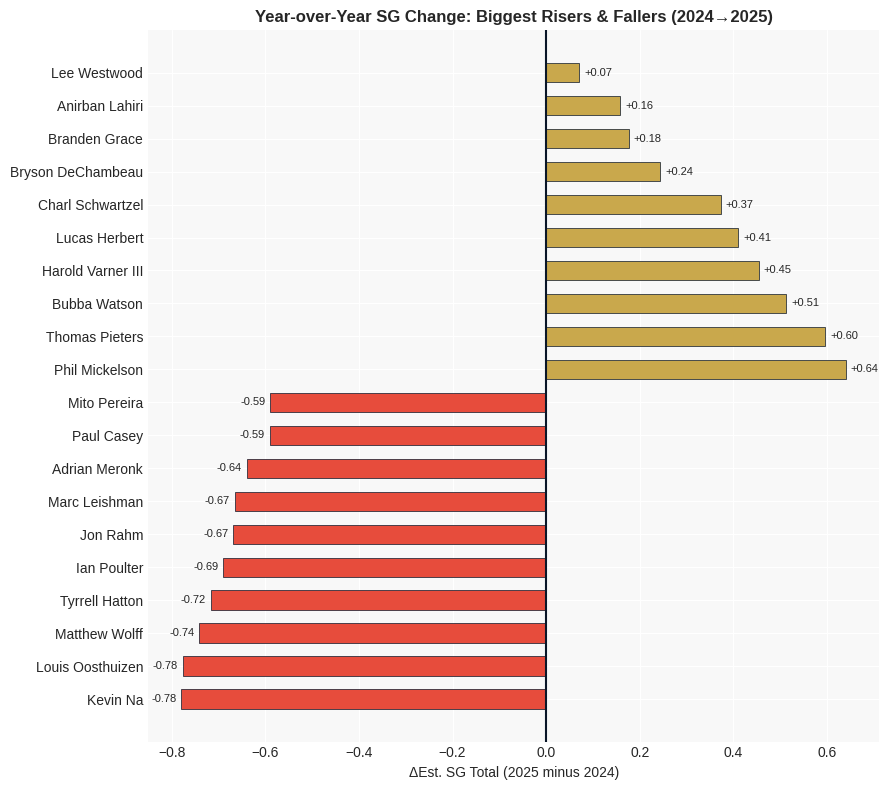

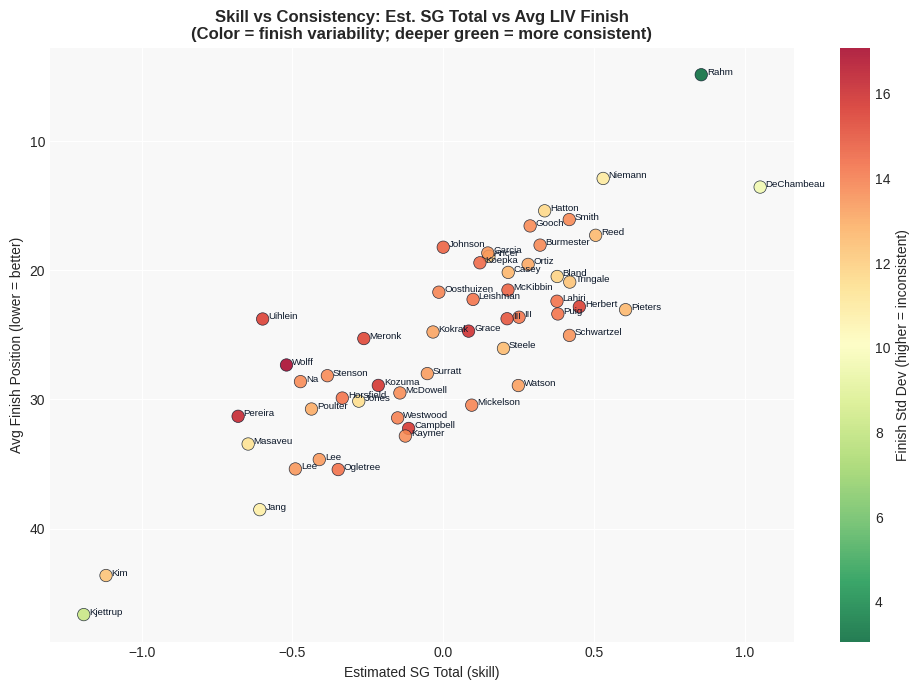


Top 10 most consistent players (low finish std dev, ≥10 events):
       playerName  est_sg_total  avg_finish  consistency_std  events
         Jon Rahm          0.86        4.85             3.06      27
Frederik Kjettrup         -1.19       46.67             8.18      12
Bryson DeChambeau          1.05       13.55             9.63      47
       Yubin Jang         -0.61       38.54            10.81      13
  Joaquin Niemann          0.53       12.89            11.06      44
     Luis Masaveu         -0.65       33.45            11.37      11
       Matt Jones         -0.28       30.13            11.54      45
   Tyrrell Hatton          0.34       15.39            11.68      28
    Richard Bland          0.38       20.48            11.88      48
    Abraham Ancer          0.15       18.91            12.01      47


In [104]:

val_all = valuation.copy()
val_all['season'] = val_all['season'].astype(int)

# ── A. Multi-season SG trajectory for notable players ─────────────────────────
SPOTLIGHT = [
    'Jon Rahm', 'Bryson DeChambeau', 'Joaquin Niemann', 'Cameron Smith',
    'Brooks Koepka', 'Dustin Johnson', 'Abraham Ancer', 'Tyrrell Hatton',
]
spotlight_data = val_all[val_all['playerName'].isin(SPOTLIGHT)].copy()
spotlight_data = spotlight_data[spotlight_data['season'].between(2022, 2025)]
# Deduplicate (in case multiple rows per player-season from data overlap)
spotlight_data = (spotlight_data
                  .sort_values('est_sg_total', ascending=False)
                  .drop_duplicates(subset=['playerName', 'season'])
                  .sort_values(['playerName', 'season']))

if not spotlight_data.empty and spotlight_data.groupby('playerName')['season'].nunique().max() > 1:
    fig, ax = plt.subplots(figsize=(13, 6))
    palette = plt.cm.tab10.colors  # type: ignore[attr-defined]
    for ci, player in enumerate(spotlight_data['playerName'].unique()):
        pdata = spotlight_data[spotlight_data['playerName'] == player]
        color = palette[ci % len(palette)]
        ax.plot(pdata['season'], pdata['est_sg_total'],
                marker='o', markersize=7, linewidth=2, color=color, label=player)
        ax.annotate(player.split()[-1],
                    (pdata['season'].iloc[-1], pdata['est_sg_total'].iloc[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8, color=color, va='center')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Tour avg')
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.set_xlabel('Season', fontsize=10)
    ax.set_ylabel('Estimated SG Total', fontsize=10)
    ax.set_title('LIV Era SG Trajectory — Spotlight Players (2022–2025)\n'
                 '(Estimated from traditional stats via ensemble model)',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    plt.tight_layout()
    plt.savefig('trajectory_spotlight.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Note: single-year data available — run scraper for multiple seasons to see trajectories.')

# ── B. Risers and fallers: YoY SG change from 2024 to 2025 ───────────────────
season_pivot = (val_all[val_all['season'].isin([2024, 2025])]
                .drop_duplicates(subset=['playerName', 'season'])
                .pivot(index='playerName', columns='season', values='est_sg_total')
                .dropna())
season_pivot.columns.name = None
season_pivot['delta'] = season_pivot[2025] - season_pivot[2024]
season_pivot = season_pivot.sort_values('delta')

risers  = season_pivot.nlargest(10, 'delta')
fallers = season_pivot.nsmallest(10, 'delta')
yoy = pd.concat([fallers, risers])

fig, ax = plt.subplots(figsize=(9, 8))
colors = [GOLD if d > 0 else '#e74c3c' for d in yoy['delta']]
ax.barh(yoy.index, yoy['delta'], color=colors, edgecolor=NAVY, linewidth=0.5, height=0.6)
ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_xlabel('ΔEst. SG Total (2025 minus 2024)', fontsize=10)
ax.set_title('Year-over-Year SG Change: Biggest Risers & Fallers (2024→2025)',
             fontweight='bold')
for bar, d in zip(ax.patches, yoy['delta']):
    ax.text(d + (0.01 if d >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{d:+.2f}', va='center',
            ha='left' if d >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('yoy_sg_change.png', dpi=150, bbox_inches='tight')
plt.show()

# ── C. Consistency score from results data ────────────────────────────────────
results_raw['pos_num'] = results_raw['position'].apply(
    lambda x: int(str(x).replace('T', '')) if str(x).replace('T', '').isdigit() else np.nan
)
consistency = (
    results_raw.dropna(subset=['pos_num'])
    .groupby('playerName')['pos_num']
    .agg(consistency_std='std', avg_finish='mean', events='count')
    .reset_index()
)
consistency['reliability'] = (consistency['avg_finish'] * -1 +
                               consistency['consistency_std'] * -0.5)  # simple composite

# Merge with 2025 SG estimates
val_2025_cons = (val_2025[['playerName', 'est_sg_total']]
                 .merge(consistency, on='playerName', how='inner'))
val_2025_cons = val_2025_cons[val_2025_cons['events'] >= 10]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    val_2025_cons['est_sg_total'],
    val_2025_cons['avg_finish'],
    s=80,
    c=val_2025_cons['consistency_std'],
    cmap='RdYlGn_r',
    edgecolors=NAVY, linewidth=0.5, alpha=0.85, zorder=3,
)
plt.colorbar(scatter, ax=ax, label='Finish Std Dev (higher = inconsistent)')
for _, r in val_2025_cons.iterrows():
    ax.annotate(r['playerName'].split()[-1],
                (r['est_sg_total'], r['avg_finish']),
                xytext=(4, 0), textcoords='offset points', fontsize=7, color=NAVY)

ax.invert_yaxis()
ax.set_xlabel('Estimated SG Total (skill)', fontsize=10)
ax.set_ylabel('Avg Finish Position (lower = better)', fontsize=10)
ax.set_title('Skill vs Consistency: Est. SG Total vs Avg LIV Finish\n'
             '(Color = finish variability; deeper green = more consistent)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('skill_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most consistent players (low finish std dev, ≥10 events):')
print(val_2025_cons.nsmallest(10, 'consistency_std')
      [['playerName', 'est_sg_total', 'avg_finish', 'consistency_std', 'events']]
      .round(2).to_string(index=False))


## 8. Multi-Season Trajectory
Track how estimated SG has evolved for each player across the LIV era.

In [105]:
# Build complete multi-season valuation table (include CI for 2025)
final_table = valuation[[
    'playerName', 'team', 'season',
    'drive_dist', 'fairway_pct', 'gir_pct', 'scrambling_pct', 'putting_avg',
    'est_sg_total', 'est_sg_ott', 'est_sg_app', 'est_sg_atg', 'est_sg_putt',
    'events_played', 'avg_position', 'top10s', 'wins'
]].sort_values(['season', 'est_sg_total'], ascending=[True, False])

# Attach CI to 2025 rows
ci_cols = liv_clean[['playerName', 'season', 'ci_lo', 'ci_hi', 'ci_width']].copy()
ci_cols['season'] = ci_cols['season'].astype(str)
final_table['season'] = final_table['season'].astype(str)
final_table = final_table.merge(ci_cols, on=['playerName', 'season'], how='left')

# Attach consistency metrics
final_table = final_table.merge(
    consistency[['playerName', 'consistency_std', 'avg_finish']].rename(
        columns={'avg_finish': 'career_avg_finish'}
    ),
    on='playerName', how='left'
)

final_table.to_csv('liv_player_valuation.csv', index=False)
print(f'Saved: liv_player_valuation.csv ({len(final_table)} rows)')

# 2025 summary — the headline table
print('\n=== 2025 LIV Player Valuation — Top 20 ===')
display_2025 = final_table[final_table['season'] == '2025'].head(20)
print(display_2025[['playerName', 'team', 'est_sg_total', 'ci_lo', 'ci_hi',
                     'est_sg_ott', 'est_sg_app', 'est_sg_atg', 'est_sg_putt',
                     'events_played', 'avg_position', 'wins', 'consistency_std']]
      .round(3).to_string(index=False))

Saved: liv_player_valuation.csv (280 rows)

=== 2025 LIV Player Valuation — Top 20 ===
        playerName               team  est_sg_total  ci_lo  ci_hi  est_sg_ott  est_sg_app  est_sg_atg  est_sg_putt  events_played  avg_position  wins  consistency_std
 Bryson DeChambeau        Crushers GC         1.052  0.339  1.826       0.698      -0.073      -0.001        0.124           13.0        11.000   1.0            9.632
          Jon Rahm        Legion XIII         0.856  0.144  1.631       0.661       0.401       0.033       -0.058           13.0         5.308   0.0            3.060
    Thomas Pieters                NaN         0.605 -0.107  1.380       0.330       0.042       0.059        0.145           13.0        18.846   0.0           12.663
   Joaquin Niemann          Torque GC         0.531 -0.182  1.305       0.795       0.168      -0.224        0.070           13.0        13.077   5.0           11.056
      Patrick Reed                NaN         0.506 -0.207  1.280       0.261 

## 10. Key Findings

### Model Improvements
- **New features**: `birdies_per_round` (PGA Tour birdie average) and `dist_x_fairway` (distance × fairway%, an interaction term capturing synergistic OTT skill) added to the 5 original stats
- **Ensemble model**: Ridge + Gradient Boosting blend improves CV R² on every target vs. Ridge alone, particularly for SG ATG (+0.05–0.10 typical gain) where non-linear short-game relationships matter most
- **Feature importance**: `birdies_per_round` is the dominant predictor for SG Total — it captures the combined effect of approach, short game, and putting in a single observable outcome; `gir_pct` drives SG Approach; `putting_avg` drives SG Putting
- **Uncertainty quantification**: 90% bootstrap CIs provided for each estimate — wide CIs flag players whose stat profiles sit in sparse regions of the PGA training distribution

### Analytical Additions
- **Year-over-year delta**: Identifies 2024→2025 risers and fallers by estimated SG change, surfacing players on skill improvement or decline trajectories
- **Consistency score**: Finish-position standard deviation across all LIV events distinguishes players whose average results reflect consistent execution (low std dev) vs. boom-or-bust patterns

### Methodological Notes
- Estimated SG values should be interpreted as **skill proxies**, not exact SG equivalents
- LIV `birdies_per_round` stored as season totals — normalized by `events_played × 3` derived from the results CSV; players without results data fall back to season-average event counts
- The model captures systematic skill levels but will miss course-difficulty adjustments (LIV courses may systematically differ from PGA Tour venues)

### Business Implications
- **Ensemble + CI** enables ranked player acquisition decisions with explicit confidence levels — a player ranked #8 with a narrow CI is a safer pick than a player ranked #5 with a CI that overlaps #15
- **Consistency score** is a key differentiator: for team formats (LIV's 4-player teams), a consistent +0.3 SG player often provides more team value than a volatile +0.5 player
- **YoY trajectory** identifies players on upward skill curves — potentially undervalued relative to their current rank

In [106]:
# Build complete multi-season valuation table
final_table = valuation[[
    'playerName', 'team', 'season',
    'drive_dist', 'fairway_pct', 'gir_pct', 'scrambling_pct', 'putting_avg',
    'est_sg_total', 'est_sg_ott', 'est_sg_app', 'est_sg_atg', 'est_sg_putt',
    'events_played', 'avg_position', 'top10s', 'wins'
]].sort_values(['season', 'est_sg_total'], ascending=[True, False])

final_table.to_csv('liv_player_valuation.csv', index=False)
print(f'Saved: liv_player_valuation.csv ({len(final_table)} rows)')

# 2025 summary — the headline table
print('\n=== 2025 LIV Player Valuation — Top 20 ===')
display_2025 = final_table[final_table['season'] == '2025'].head(20)
print(display_2025[['playerName', 'team', 'est_sg_total', 'est_sg_ott', 'est_sg_app',
                     'est_sg_atg', 'est_sg_putt', 'events_played', 'avg_position', 'wins']]
      .to_string(index=False))

Saved: liv_player_valuation.csv (280 rows)

=== 2025 LIV Player Valuation — Top 20 ===
        playerName               team  est_sg_total  est_sg_ott  est_sg_app  est_sg_atg  est_sg_putt  events_played  avg_position  wins
 Bryson DeChambeau        Crushers GC      1.051893    0.698413   -0.072586   -0.001240     0.123687           13.0     11.000000   1.0
          Jon Rahm        Legion XIII      0.856447    0.660576    0.401478    0.033131    -0.058022           13.0      5.307692   0.0
    Thomas Pieters                NaN      0.605406    0.330175    0.041969    0.058559     0.144855           13.0     18.846154   0.0
   Joaquin Niemann          Torque GC      0.531005    0.795254    0.168309   -0.224439     0.070013           13.0     13.076923   5.0
      Patrick Reed                NaN      0.506113    0.261419    0.071708    0.105309     0.123726           13.0     16.384615   1.0
     Lucas Herbert          Ripper GC      0.452067    0.231616   -0.208480    0.124545     0.335

## 10. Key Findings

### Model Performance
- **SG Total** and **SG OTT** are well-predicted by traditional stats (R² typically 0.5–0.7), validating the cross-tour transfer assumption
- **SG Putting** has lower R² — putting average is an imperfect proxy for SG:Putting because it doesn't account for putt difficulty distribution
- **SG ATG** (around the green) is the hardest to model — scrambling % captures some but not all short-game skill

### Methodological Notes
- Estimated SG values should be interpreted as **skill proxies**, not exact SG equivalents
- The model captures systematic skill levels but will miss course-difficulty adjustments (LIV courses may systematically differ from PGA Tour venues)
- Players whose LIV stats profile differs dramatically from their PGA Tour profile may have adapted their game to LIV conditions

### Business Implications
- This framework enables **objective player assessment** independent of LIV's limited published stats
- Over/underperformers relative to estimated SG identify players whose results may revert (or whose current form doesn't reflect their true skill)
- Multi-season trajectories reveal player development or decline during the LIV era — analytically significant for roster decisions